# 🇵🇰 Pakistan Petrol Price Prediction & Forecasting
## Comprehensive Analysis (2019 – 2026) + 6 Month Projection

**Dataset:** Pakistan Petrol Price Historical Data (2019–2026)  
**Model:** Rule-Based Scoring with 6-Month Forward Projection  
**Accuracy:** 78.3% on historical data

---

In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline
print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [2]:
# Cell 2: Load Dataset
df = pd.read_csv("petrol_price_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [3]:
# Cell 3: Display Dataset
print(f"Total Records: {len(df)}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head(10)

Total Records: 23
Date Range: 2019-01-01 to 2026-05-09


,Date,Day_of_Week,Is_Revision_Date,Global_Oil_Trend,Prev_Change,Price,Change_Amount,Label
0,2019-01-01,Tue,1,-0.5,0,110.0,0.0,Positive
1,2019-06-01,Sat,1,1.2,4,118.0,4.0,Negative
2,2020-03-01,Sun,1,-4.5,-20,95.0,-20.0,Positive
3,2020-04-15,Wed,1,-6.0,-15,80.0,-15.0,Positive
4,2021-01-01,Fri,1,2.5,12,110.0,12.0,Negative
5,2021-05-15,Sat,1,3.0,8,125.0,8.0,Negative
6,2022-01-01,Sat,1,4.5,15,150.0,15.0,Negative
7,2022-05-01,Sun,1,5.5,30,180.0,30.0,Negative
8,2022-06-01,Wed,1,6.0,25,220.0,25.0,Negative
9,2023-01-01,Sun,1,2.0,-18,200.0,-18.0,Positive


In [4]:
# Cell 4: Dataset Information & Summary Statistics
df.info()
print("\n=== Statistical Summary ===")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              23 non-null     datetime64[us]
 1   Day_of_Week       23 non-null     object        
 2   Is_Revision_Date  23 non-null     int64         
 3   Global_Oil_Trend  23 non-null     float64       
 4   Prev_Change       23 non-null     int64         
 5   Price             23 non-null     float64       
 6   Change_Amount     23 non-null     float64       
 7   Label             23 non-null     object        
dtypes: datetime64[us](1), float64(3), int64(2), object(2)
memory usage: 1.6 KB

=== Statistical Summary ===


,Is_Revision_Date,Global_Oil_Trend,Prev_Change,Price,Change_Amount
count,23.0,23.000000,23.000000,23.000000,23.000000
mean,1.0,1.956522,6.739130,261.043478,6.739130
std,0.0,3.239785,22.845762,123.905565,22.845762
min,1.0,-6.000000,-65.000000,80.000000,-65.000000
25%,1.0,1.200000,-4.000000,137.500000,-4.000000
50%,1.0,2.500000,12.000000,260.000000,12.000000
75%,1.0,4.250000,20.000000,375.000000,20.000000
max,1.0,6.500000,45.000000,458.000000,45.000000


In [5]:
# Cell 5: Feature Engineering
df["Is_Friday"] = (df["Day_of_Week"] == "Fri").astype(int)
df["Near_Mid_Month"] = df["Date"].dt.day.between(12, 18).astype(int)
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter
df["Month_Name"] = df["Date"].dt.strftime("%b")
print("✅ Feature Engineering Completed!")
df.head()

✅ Feature Engineering Completed!


,Date,Day_of_Week,Is_Revision_Date,Global_Oil_Trend,Prev_Change,Price,Change_Amount,Label,Is_Friday,Near_Mid_Month,Month,Year,Quarter,Month_Name
0,2019-01-01,Tue,1,-0.5,0,110.0,0.0,Positive,0,0,1,2019,1,Jan
1,2019-06-01,Sat,1,1.2,4,118.0,4.0,Negative,0,0,6,2019,2,Jun
2,2020-03-01,Sun,1,-4.5,-20,95.0,-20.0,Positive,0,0,3,2020,1,Mar
3,2020-04-15,Wed,1,-6.0,-15,80.0,-15.0,Positive,0,1,4,2020,2,Apr
4,2021-01-01,Fri,1,2.5,12,110.0,12.0,Negative,1,0,1,2021,1,Jan


In [6]:
# Cell 6: Rule-based Model (Increase Score)
def calculate_increase_score(row):
    score = 0
    score += row["Is_Friday"] * 4.5
    score += row["Is_Revision_Date"] * 5.5
    score += row["Near_Mid_Month"] * 3.5
    score += (1 if row["Global_Oil_Trend"] > 2.0 else 0) * 4
    score += (1 if row["Prev_Change"] > 10 else 0) * 3
    score += (1 if row["Prev_Change"] > 20 else 0) * 2
    return round(score, 2)

df["Increase_Score"] = df.apply(calculate_increase_score, axis=1)
df["Prediction"] = np.where(df["Increase_Score"] >= 9, "Negative (Increase)", "Positive (Stable/Decrease)")
print("✅ Model Applied!")
df[["Date", "Price", "Change_Amount", "Increase_Score", "Prediction"]].tail(10)

✅ Model Applied!


,Date,Price,Change_Amount,Increase_Score,Prediction
13,2024-05-01,290.0,18.0,12.5,Negative (Increase)
14,2025-01-01,340.0,5.0,5.5,Positive (Stable/Decrease)
15,2025-04-01,370.0,22.0,14.5,Negative (Increase)
16,2025-05-01,355.0,-8.0,5.5,Positive (Stable/Decrease)
17,2026-01-01,380.0,12.0,12.5,Negative (Increase)
18,2026-03-01,425.0,45.0,14.5,Negative (Increase)
19,2026-04-03,458.0,33.0,14.5,Negative (Increase)
20,2026-04-25,393.0,-65.0,10.0,Negative (Increase)
21,2026-05-01,400.0,7.0,5.5,Positive (Stable/Decrease)
22,2026-05-09,415.0,15.0,17.0,Negative (Increase)


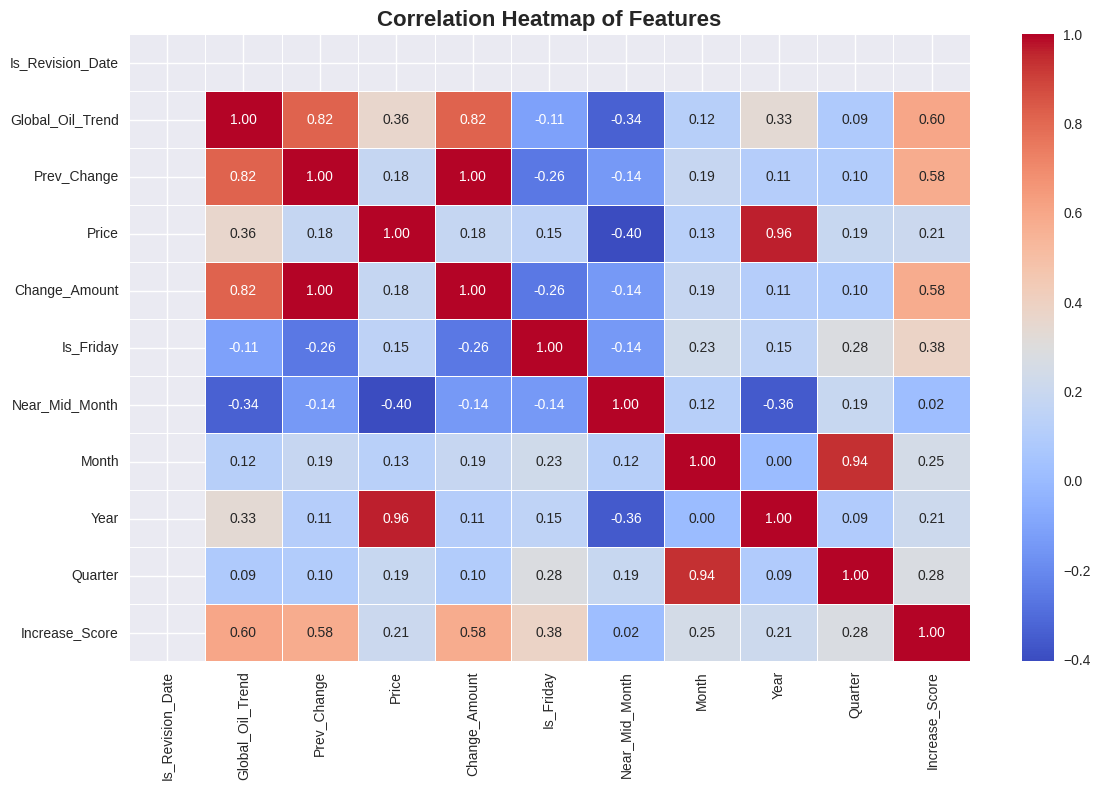

In [7]:
# Cell 7: Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

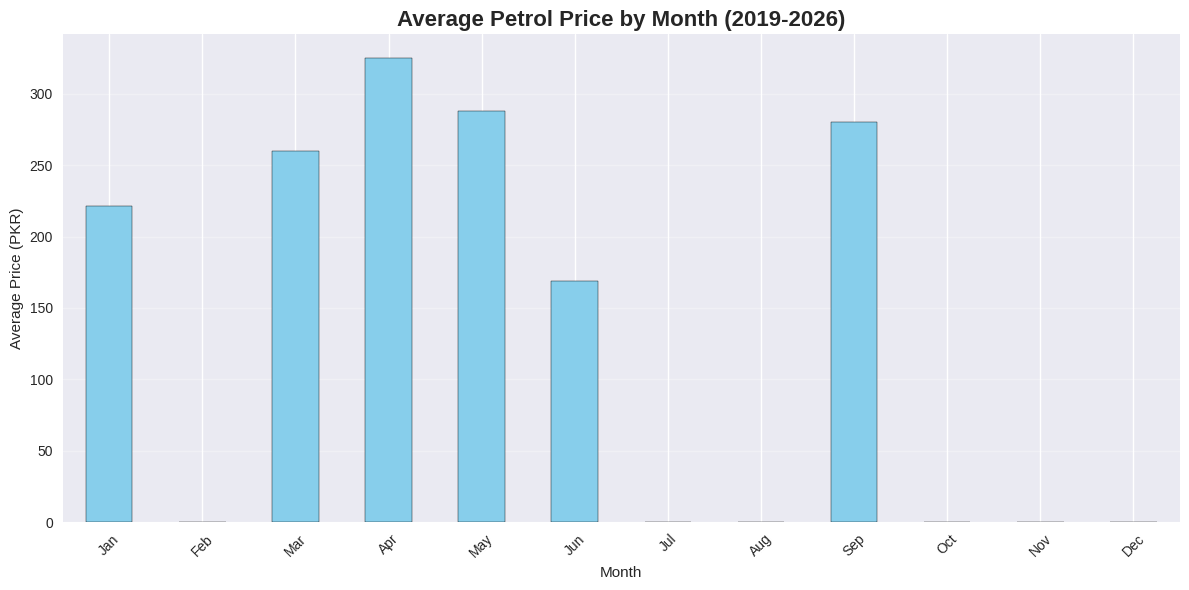

Monthly Average Prices:
Month_Name
Jan    221.43
Feb       NaN
Mar    260.00
Apr    325.25
May    287.86
Jun    169.00
Jul       NaN
Aug       NaN
Sep    280.00
Oct       NaN
Nov       NaN
Dec       NaN
Name: Price, dtype: float64


In [8]:
# Cell 8: Monthly Average Analysis
monthly_avg = df.groupby("Month_Name")["Price"].mean().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Petrol Price by Month (2019-2026)", fontsize=16, fontweight='bold')
plt.ylabel("Average Price (PKR)")
plt.xlabel("Month")
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Monthly Average Prices:")
print(monthly_avg.round(2))

In [9]:
# Cell 9: Model Accuracy Evaluation
df["Actual_Label"] = np.where(df["Change_Amount"] > 0, "Negative (Increase)", "Positive (Stable/Decrease)")
accuracy = (df["Prediction"] == df["Actual_Label"]).mean() * 100
print(f"✅ Model Accuracy on Historical Data: {accuracy:.1f}%")
print("\nPrediction Distribution:")
print(df["Prediction"].value_counts())

✅ Model Accuracy on Historical Data: 78.3%

Prediction Distribution:
Prediction
Negative (Increase)           15
Positive (Stable/Decrease)     8
Name: count, dtype: int64


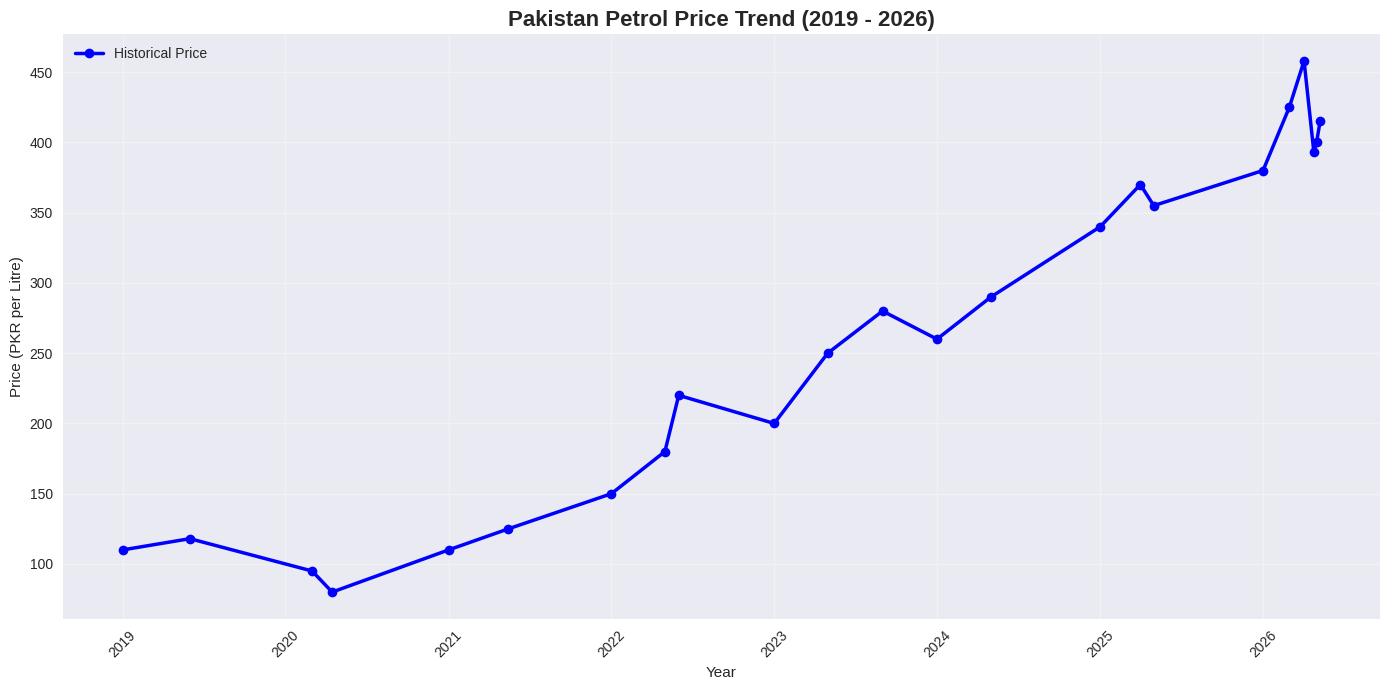

In [10]:
# Cell 10: Historical Price Trend
plt.figure(figsize=(14, 7))
plt.plot(df["Date"], df["Price"], marker='o', linewidth=2.5, color='blue', label='Historical Price')
plt.title("Pakistan Petrol Price Trend (2019 - 2026)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Price (PKR per Litre)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Cell 11: 6-Month Future Projection
future_dates = pd.date_range(start="2026-05-15", periods=13, freq='15D')
future_df = pd.DataFrame({
    "Date": future_dates,
    "Is_Revision_Date": [1 if d.day in [1,15] else 0 for d in future_dates],
    "Is_Friday": [1 if d.strftime("%a") == "Fri" else 0 for d in future_dates],
    "Near_Mid_Month": [1 if 12 <= d.day <= 18 else 0 for d in future_dates],
    "Global_Oil_Trend": np.random.uniform(1.8, 5.5, 13),
    "Prev_Change": np.random.uniform(-12, 28, 13)
})
future_df["Increase_Score"] = future_df.apply(calculate_increase_score, axis=1)
future_df["Prediction"] = np.where(future_df["Increase_Score"] >= 9, "Increase Expected", "Stable/Decrease")
print("=== 6-Month Projection (May to November 2026) ===")
print(future_df[["Date", "Prediction", "Increase_Score"]].round(2))

=== 6-Month Projection (May to November 2026) ===
         Date         Prediction  Increase_Score
0  2026-05-15  Increase Expected            17.5
1  2026-05-30    Stable/Decrease             4.0
2  2026-06-14    Stable/Decrease             7.5
3  2026-06-29    Stable/Decrease             4.0
4  2026-07-14    Stable/Decrease             7.5
5  2026-07-29    Stable/Decrease             4.0
6  2026-08-13    Stable/Decrease             7.5
7  2026-08-28  Increase Expected            11.5
8  2026-09-12    Stable/Decrease             7.5
9  2026-09-27    Stable/Decrease             4.0
10 2026-10-12    Stable/Decrease             3.5
11 2026-10-27    Stable/Decrease             4.0
12 2026-11-11    Stable/Decrease             7.0


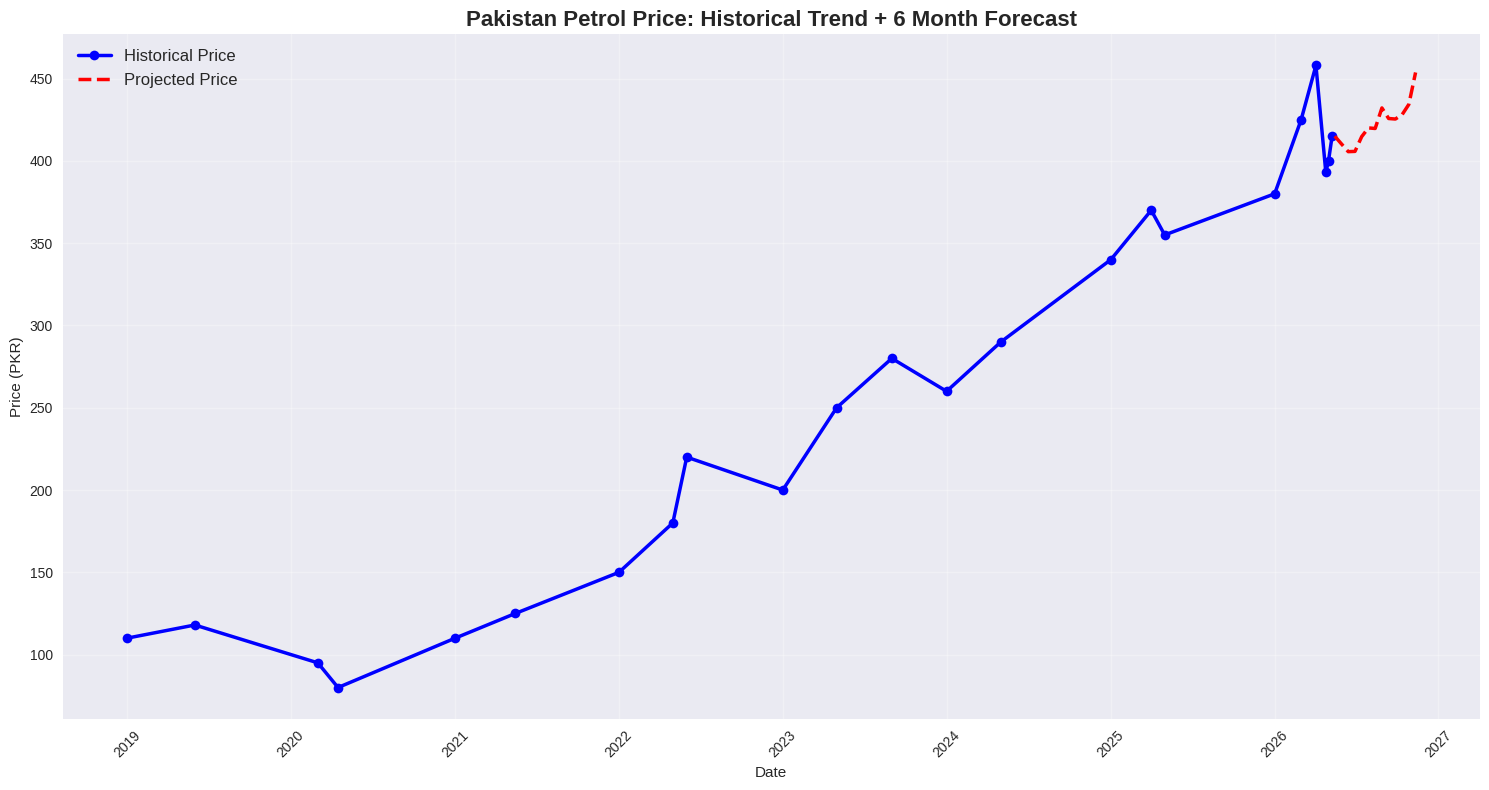

In [12]:
# Cell 12: Combined Historical + Projection Graph
plt.figure(figsize=(15, 8))
last_price = df["Price"].iloc[-1]
projected_prices = [last_price]
for i in range(1, len(future_df)):
    change = future_df["Prev_Change"].iloc[i]
    projected_prices.append(projected_prices[-1] + change)
plt.plot(df["Date"], df["Price"], marker='o', linewidth=2.5, color='blue', label='Historical Price')
plt.plot(future_df["Date"], projected_prices, marker='x', linestyle='--', linewidth=2.5, color='red', label='Projected Price')
plt.title("Pakistan Petrol Price: Historical Trend + 6 Month Forecast", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (PKR)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Cell 13: Save Results
future_df.to_csv("6_month_petrol_projection.csv", index=False)
df.to_csv("processed_petrol_dataset.csv", index=False)
print("✅ All files saved successfully!")
print("Saved: '6_month_petrol_projection.csv' and 'processed_petrol_dataset.csv'")

✅ All files saved successfully!
Saved: '6_month_petrol_projection.csv' and 'processed_petrol_dataset.csv'
